In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

data_dir = Path("../data")
paths = sorted(data_dir.glob("*_vac.csv")) + sorted(data_dir.glob("*_air.csv"))

# Load all traces once (time in µs, voltage flipped)
t_list = []
v_list = []

for path in paths:
    t, v = np.loadtxt(path, delimiter=",", unpack=True)
    t_list.append(t)
    v_list.append(-v)

# Optional sanity check:
paths

[WindowsPath('../data/1_vac.csv'),
 WindowsPath('../data/2_vac.csv'),
 WindowsPath('../data/3_vac.csv'),
 WindowsPath('../data/4_vac.csv'),
 WindowsPath('../data/5_vac.csv'),
 WindowsPath('../data/1_air.csv'),
 WindowsPath('../data/2_air.csv'),
 WindowsPath('../data/3_air.csv'),
 WindowsPath('../data/4_air.csv'),
 WindowsPath('../data/5_air.csv')]

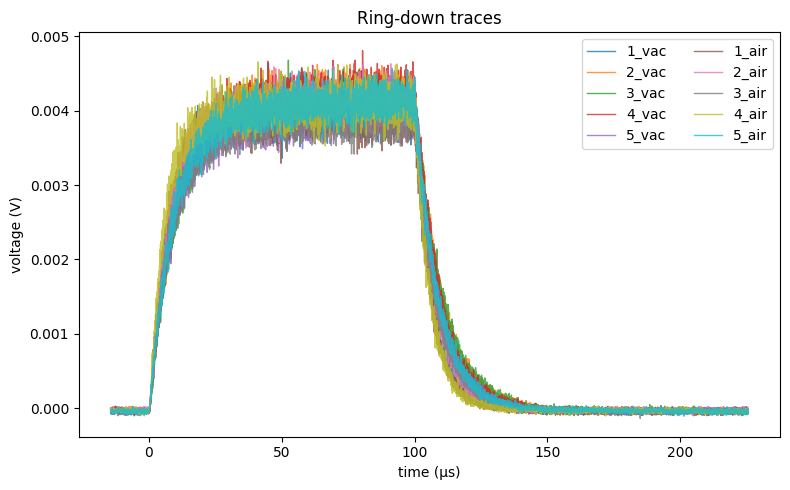

In [2]:
plt.figure(figsize=(8,5))
for i, path in enumerate(paths):
    t = t_list[i] * 1e6  # s -> µs (plot only)
    v = v_list[i]
    plt.plot(t, v, label=path.stem, linewidth=1, alpha=0.8)

plt.xlabel("time (μs)")
plt.ylabel("voltage (V)")
plt.title("Ring-down traces")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [3]:
# for i, path in enumerate(paths):
#     t = t_list[i] * 1e6
#     v = v_list[i]
#     plt.figure(figsize=(8,4))
#     plt.plot(t, v)
#     plt.title(path.stem)
#     plt.xlabel("time (μs)")
#     plt.ylabel("voltage (V)")
#     plt.tight_layout()
#     plt.show()

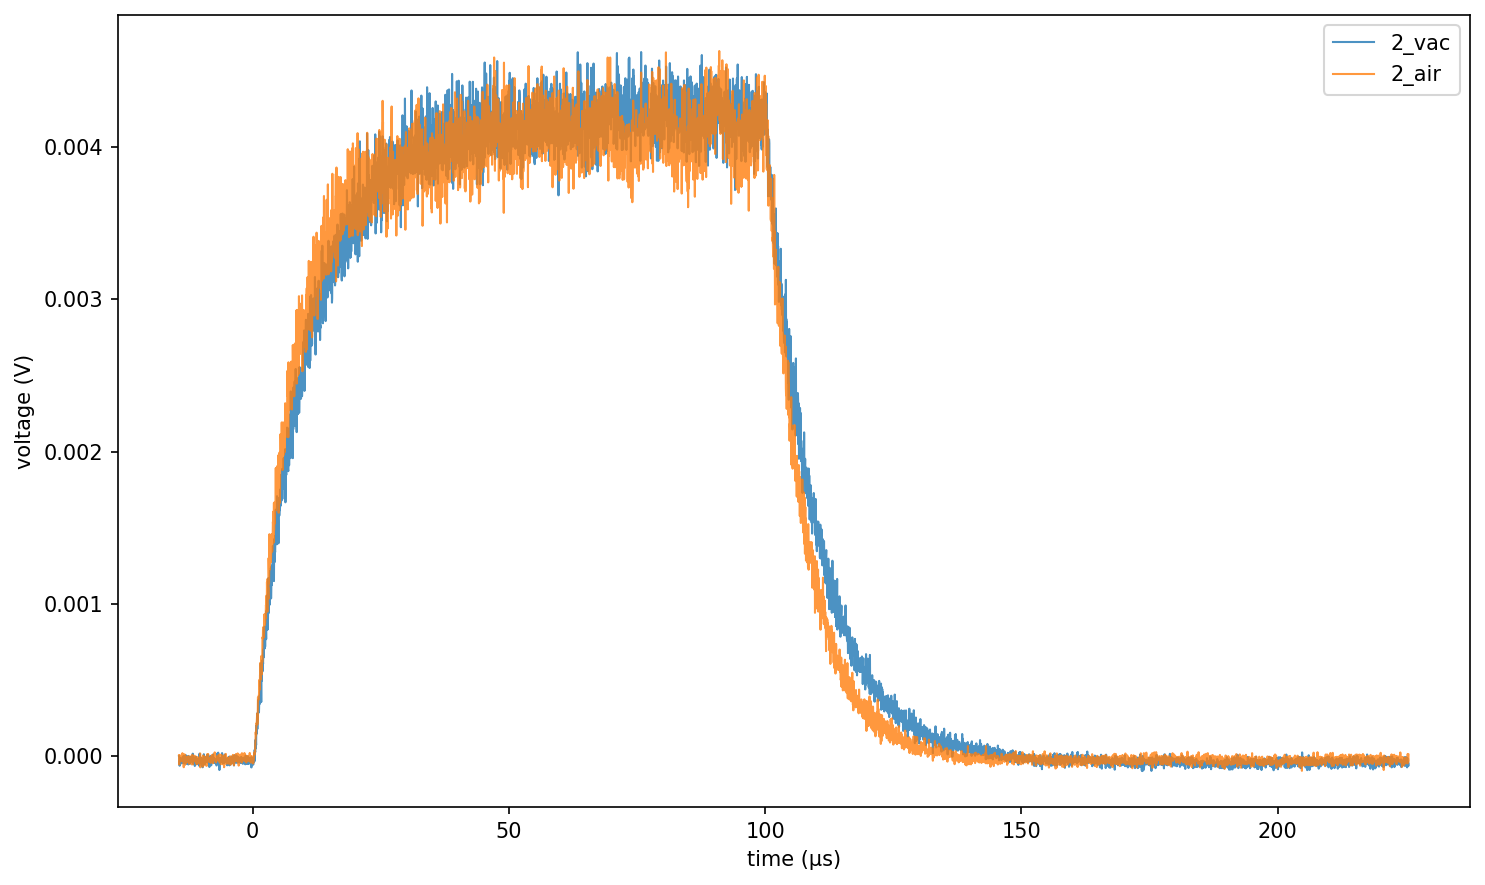

In [4]:
idxs = [1, 6]  # pair of measurements x_vac and x_air

plt.figure(figsize=(10,6), dpi=150)
for i in idxs:
    t = t_list[i] * 1e6
    v = v_list[i]
    plt.plot(t, v, label=paths[i].stem, linewidth=1, alpha=0.8)

# plt.title(f"Overlay: {paths[idxs[0]].stem} vs {paths[idxs[1]].stem}")
plt.xlabel("time (μs)")
plt.ylabel("voltage (V)")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/raw_overlay_2_vac_2_air.png")
plt.show()

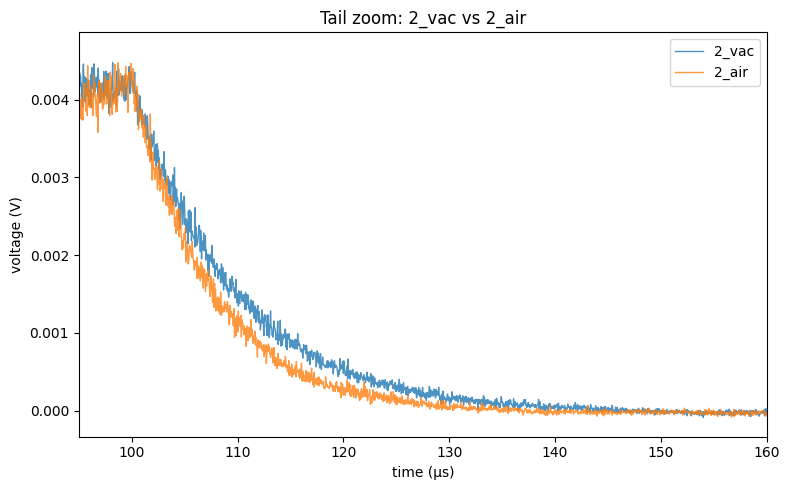

In [5]:
plt.figure(figsize=(8,5))
for i in idxs:
    t = t_list[i] * 1e6
    v = v_list[i]
    plt.plot(t, v, label=paths[i].stem, linewidth=1, alpha=0.8)

plt.xlim(95, 160)
plt.title(f"Tail zoom: {paths[idxs[0]].stem} vs {paths[idxs[1]].stem}")
plt.xlabel("time (μs)")
plt.ylabel("voltage (V)")
plt.legend()
plt.tight_layout()
plt.show()

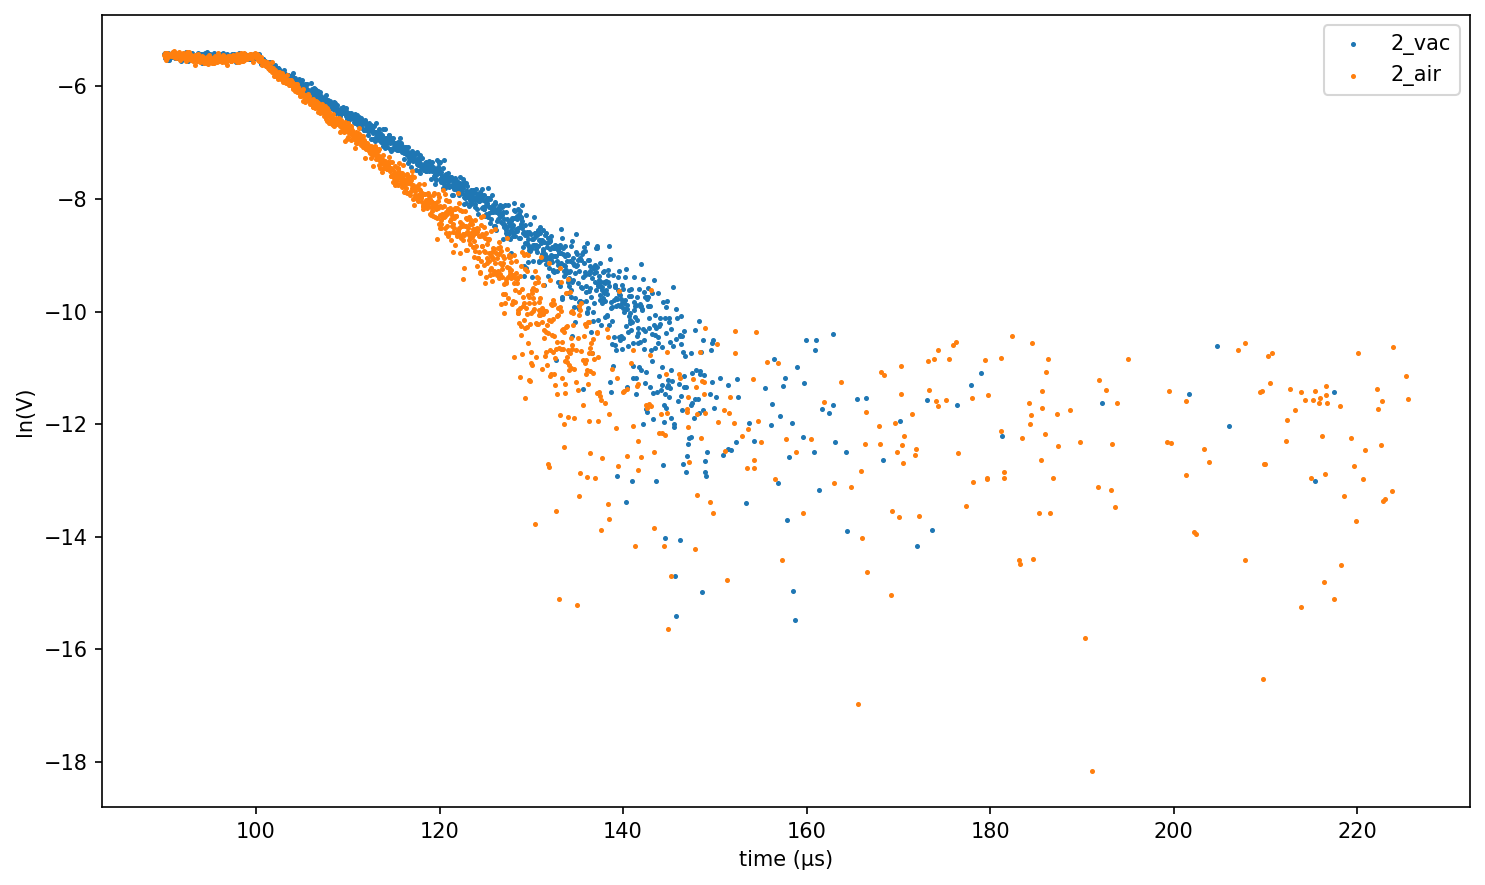

In [6]:
plt.figure(figsize=(10,6), dpi=150)

for i in idxs:
    t = t_list[i]
    v = v_list[i]
    t_us = t * 1e6

    # Wide view: include a bit before pulse end to justify t_start,
    # and go all the way into the noise region.
    mask = (t_us >= 90)

    # For the log plot we can only use positive values (late times can cross zero due to noise)
    plt.scatter(t_us[mask][v[mask] > 0], np.log(v[mask][v[mask] > 0]),
                s=2, label=paths[i].stem)

plt.xlabel("time (µs)")
plt.ylabel("ln(V)")
# plt.title("Exploratory semilog: raw signal (no baseline subtraction)")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/semilog_exploratory_2_vac_2_air.png")
plt.show()

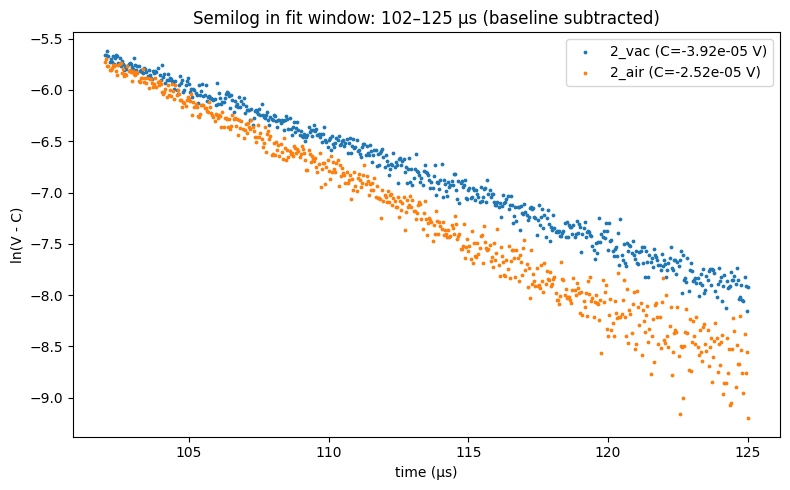

In [7]:
t_start = 102
t_end = 125
t_noise = 160

plt.figure(figsize=(8,5))

for i in idxs:
    t = t_list[i]
    v = v_list[i]
    t_us = t * 1e6

    # Baseline offset C: average late-time region where the ring-down has decayed (signal ≈ noise)
    C = np.mean(v[t_us >= t_noise])

    # Start of ring-down: laser pulse lasts ~100 µs, so for t_us >= 100 µs the cavity is no longer pumped, conservatively choose 102
    mask = (t_us >= t_start) & (t_us <= t_end)

    # y is the ring-down signal above the baseline: V(t) - C  ∝  exp(-t/τ)
    y = v[mask] - C

    plt.scatter(t_us[mask][y > 0], np.log(y[y > 0]),
                s=3, label=f"{paths[i].stem} (C={C:.2e} V)")

plt.xlabel("time (µs)")
plt.ylabel("ln(V - C)")
plt.title(f"Semilog in fit window: {t_start}–{t_end} µs (baseline subtracted)")
plt.legend()
plt.tight_layout()
plt.show()

---

2_vac: slope b = -1.011e+05 ± 4.6e+02 1/s, tau = 9.90 ± 0.04 µs, R^2 = 0.98829
2_air: slope b = -1.324e+05 ± 8.3e+02 1/s, tau = 7.55 ± 0.05 µs, R^2 = 0.97781


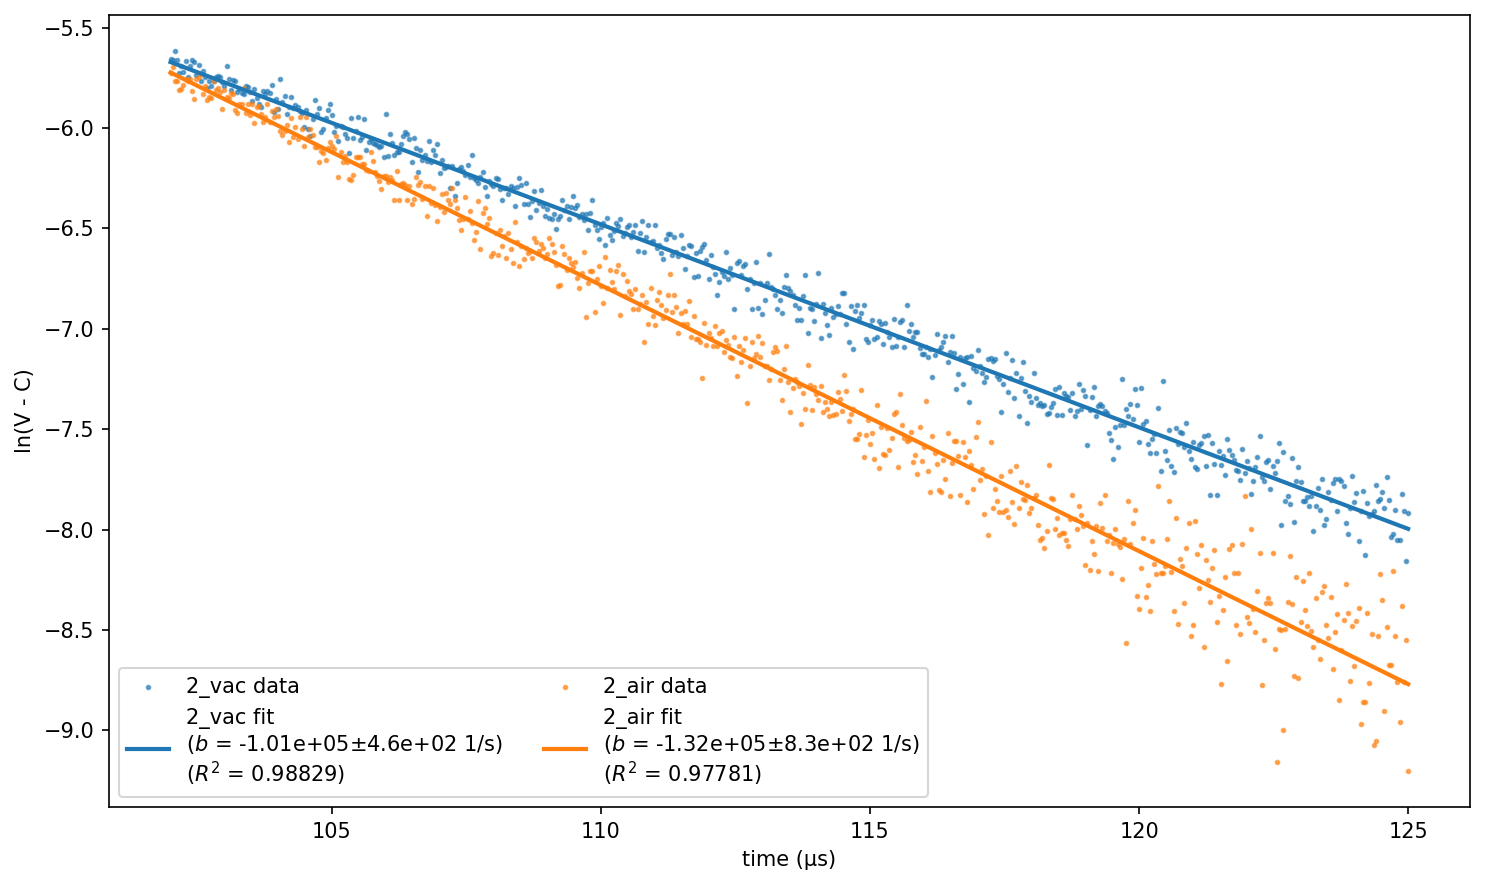

In [8]:
plt.figure(figsize=(10,6), dpi=150)

for i in idxs:
    t = t_list[i]          # seconds
    v = v_list[i]
    t_us = t * 1e6

    # baseline offset from late-time region
    C = np.mean(v[t_us >= t_noise])

    # fit window (in µs for readability)
    mask = (t_us >= t_start) & (t_us <= t_end)

    # linearized data: ln(V - C)
    y = v[mask] - C
    x_fit = t[mask][y > 0]         # seconds
    y_fit = np.log(y[y > 0])       # ln(V - C)

    # OLS line fit: y_fit ≈ a + b*x_fit  with b = -1/tau
    (b, a), cov = np.polyfit(x_fit, y_fit, deg=1, cov=True)

    tau = -1 / b
    b_err = np.sqrt(cov[0, 0])
    tau_err = b_err / (b**2)

    # R^2 for the linear fit in the (t, ln(y)) domain
    y_hat = a + b * x_fit
    ss_res = np.sum((y_fit - y_hat)**2)
    ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
    R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    print(
        f"{paths[i].stem}: "
        f"slope b = {b:.3e} ± {b_err:.1e} 1/s, "
        f"tau = {tau*1e6:.2f} ± {tau_err*1e6:.2f} µs, "
        f"R^2 = {R2:.5f}"
    )

    # plot data + fitted line on the same axes
    plt.scatter(x_fit * 1e6, y_fit, s=3, alpha=0.6, label=f"{paths[i].stem} data")

    x_line = np.linspace(x_fit.min(), x_fit.max(), 200)
    y_line = a + b * x_line
    plt.plot(
        x_line * 1e6, y_line, linewidth=2,
        label=(
            f"{paths[i].stem} fit\n"
            f"($b$ = {b:.2e}±{b_err:.1e} 1/s)\n"
            f"($R^2$ = {R2:.5f})"
        )
    )

plt.xlabel("time (µs)")
plt.ylabel("ln(V - C)")
# plt.title(f"Linear regression in fit window: {t_start}–{t_end} µs")
plt.legend(loc='lower left', ncol=2)
plt.tight_layout()
plt.savefig("../figures/linreg_fit_2_vac_2_air.png")
plt.show()

In [9]:
b_list = []
b_err_list = []
tau_list = []
tau_err_list = []
C_list = []

for i, path in enumerate(paths):
    t = t_list[i]      # seconds
    v = v_list[i]
    t_us = t * 1e6

    # baseline offset from late-time region
    C = np.mean(v[t_us >= t_noise])

    # fit window
    mask = (t_us >= t_start) & (t_us <= t_end)

    # linearized data
    y = v[mask] - C
    x_fit = t[mask][y > 0]         # seconds
    y_fit = np.log(y[y > 0])

    # OLS line fit: y_fit ≈ a + b*x_fit
    (b, a), cov = np.polyfit(x_fit, y_fit, deg=1, cov=True)
    b_err = np.sqrt(cov[0, 0])

    tau = -1 / b
    tau_err = b_err / (b**2)

    b_list.append(b)
    b_err_list.append(b_err)
    tau_list.append(tau)
    tau_err_list.append(tau_err)
    C_list.append(C)

    print(
        f"{path.stem:6s}: "
        f"b = {b:.3e} ± {b_err:.1e} 1/s, "
        f"tau = {tau*1e6:6.2f} ± {tau_err*1e6:5.2f} µs, "
        f"C = {C:.2e} V"
    )

1_vac : b = -1.402e+05 ± 9.1e+02 1/s, tau =   7.13 ±  0.05 µs, C = -3.13e-05 V
2_vac : b = -1.011e+05 ± 4.6e+02 1/s, tau =   9.90 ±  0.04 µs, C = -3.92e-05 V
3_vac : b = -9.791e+04 ± 4.4e+02 1/s, tau =  10.21 ±  0.05 µs, C = -2.30e-05 V
4_vac : b = -1.089e+05 ± 5.4e+02 1/s, tau =   9.19 ±  0.05 µs, C = -3.75e-05 V
5_vac : b = -1.116e+05 ± 6.3e+02 1/s, tau =   8.96 ±  0.05 µs, C = -3.80e-05 V
1_air : b = -1.522e+05 ± 1.1e+03 1/s, tau =   6.57 ±  0.05 µs, C = -4.29e-05 V
2_air : b = -1.324e+05 ± 8.3e+02 1/s, tau =   7.55 ±  0.05 µs, C = -2.52e-05 V
3_air : b = -1.191e+05 ± 6.6e+02 1/s, tau =   8.40 ±  0.05 µs, C = -3.66e-05 V
4_air : b = -1.623e+05 ± 1.2e+03 1/s, tau =   6.16 ±  0.05 µs, C = -3.32e-05 V
5_air : b = -1.122e+05 ± 5.9e+02 1/s, tau =   8.91 ±  0.05 µs, C = -3.62e-05 V


In [10]:
c = 299_792_458.0  # m/s

beta_list = []
beta_err_list = []

scale = 1e-5  # print everything as (...) × 10^-5 1/m

print("Pair-wise results:")
for i in range(5):
    tau0 = tau_list[i]          # seconds (vac)
    dtau0 = tau_err_list[i]
    tau = tau_list[i + 5]       # seconds (air)
    dtau = tau_err_list[i + 5]

    beta = (1.0 / c) * (1.0 / tau - 1.0 / tau0)
    beta_err = (1.0 / c) * np.sqrt((dtau / (tau**2))**2 + (dtau0 / (tau0**2))**2)

    beta_list.append(beta)
    beta_err_list.append(beta_err)

    print(f"i={i+1}: beta=({beta/scale:.3f}±{beta_err/scale:.3f})×10^-5 1/m")

beta_arr = np.array(beta_list)
beta_err_arr = np.array(beta_err_list)

beta_mean = np.mean(beta_arr)
beta_std = np.std(beta_arr, ddof=1)
beta_sem = beta_std / np.sqrt(len(beta_arr))

print("\nFinal result (mean over 5 pairs):")
print(f"beta_mean = ({beta_mean/scale:.3f}±{beta_sem/scale:.3f})×10^-5 1/m")

# "Without pair 5" (i = 1..4 only)
beta_arr_4 = beta_arr[:4]

beta_mean_4 = np.mean(beta_arr_4)
beta_std_4 = np.std(beta_arr_4, ddof=1)
beta_sem_4 = beta_std_4 / np.sqrt(len(beta_arr_4))

print("\nExcluding pair 5 (use i=1..4):")
print(f"beta_mean = ({beta_mean_4/scale:.3f}±{beta_sem_4/scale:.3f})×10^-5 1/m")

Pair-wise results:
i=1: beta=(4.011±0.468)×10^-5 1/m
i=2: beta=(10.458±0.317)×10^-5 1/m
i=3: beta=(7.060±0.264)×10^-5 1/m
i=4: beta=(17.826±0.442)×10^-5 1/m
i=5: beta=(0.194±0.288)×10^-5 1/m

Final result (mean over 5 pairs):
beta_mean = (7.910±3.002)×10^-5 1/m

Excluding pair 5 (use i=1..4):
beta_mean = (9.839±2.970)×10^-5 1/m


In [11]:
# =========================
# Load temperature/pressure
# =========================
# temps_pressures.csv: column 1 = T in °C, column 2 = p in mbar
path_tp = Path("../data/temps_pressures.csv")
T_C, p_mbar = np.loadtxt(path_tp, delimiter=",", unpack=True)

# Convert to SI
T_K = T_C + 273.15          # K
p_Pa = p_mbar * 100.0       # Pa  (1 mbar = 100 Pa)

# Uncertainties (as discussed)
dT_C = 0.1                  # °C (reading uncertainty)
dp_mbar = 2.0               # mbar (device accuracy dominates; 0.1 mbar digit negligible)

dT_K = dT_C                 # same increment in K
dp_Pa = dp_mbar * 100.0     # Pa

print("Loaded temperature/pressure data:")
for i in range(len(T_C)):
    print(f"pair {i+1}: T = {T_C[i]:.1f} °C, p = {p_mbar[i]:.1f} mbar")

# =========================
# Constants and assumptions
# =========================
kB = 1.380649e-23           # J/K (exact in SI)
c = 299_792_458.0           # m/s (exact in SI)

lam = 405e-9                # m  (laser wavelength; uncertainty not given, neglected)
n_air = 1.00028275          # refractive index at 0.400 µm from the table (used as approx for 405 nm)

# =========================
# Theoretical calculation
# =========================
# Use mean p, T
p_mean = np.mean(p_Pa)
T_mean = np.mean(T_K)

# Number density N = p / (kB T)
N_mean = p_mean / (kB * T_mean)

# Error propagation for N(p,T):
# dN^2 = (∂N/∂p dp)^2 + (∂N/∂T dT)^2
dN = np.sqrt((dp_Pa / (kB * T_mean))**2 + ((N_mean / T_mean) * dT_K)**2)

# Theoretical Rayleigh scattering coefficient
beta_th = (8 * np.pi**3 / (3 * N_mean * lam**4)) * (n_air**2 - 1.0)**2

# Propagate uncertainty from N only (λ and n treated as exact here)
beta_th_err = beta_th * (dN / N_mean)

# =========================
# Print results
# =========================
print("\nMeans:")
print(f"T_mean = {np.mean(T_C):.2f} °C  ({T_mean:.2f} K)")
print(f"p_mean = {np.mean(p_mbar):.2f} mbar ({p_mean:.1f} Pa)")

print("\nAssumed uncertainties:")
print(f"ΔT = {dT_C:.1f} °C")
print(f"Δp = {dp_mbar:.1f} mbar")

print("\nConstants used:")
print(f"kB = {kB:.6e} J/K (exact)")
print(f"λ = {lam*1e9:.1f} nm (assumed exact)")
print(f"n = {n_air:.8f} (from 0.400 µm table value, used for 405 nm)")

print("\nNumber density (from mean p, T):")
print(f"N = {N_mean:.4e} 1/m^3")
print(f"ΔN = {dN:.2e} 1/m^3  (relative {dN/N_mean:.2e})")

print("\nTheoretical β (from mean p, T):")
print(f"β_th = {beta_th:.3e} 1/m")
print(f"Δβ_th = {beta_th_err:.1e} 1/m")

Loaded temperature/pressure data:
pair 1: T = 19.8 °C, p = 1020.2 mbar
pair 2: T = 20.0 °C, p = 1017.4 mbar
pair 3: T = 20.2 °C, p = 1015.2 mbar
pair 4: T = 20.1 °C, p = 1018.0 mbar
pair 5: T = 20.3 °C, p = 1019.7 mbar

Means:
T_mean = 20.08 °C  (293.23 K)
p_mean = 1018.10 mbar (101810.0 Pa)

Assumed uncertainties:
ΔT = 0.1 °C
Δp = 2.0 mbar

Constants used:
kB = 1.380649e-23 J/K (exact)
λ = 405.0 nm (assumed exact)
n = 1.00028275 (from 0.400 µm table value, used for 405 nm)

Number density (from mean p, T):
N = 2.5148e+25 1/m^3
ΔN = 5.01e+22 1/m^3  (relative 1.99e-03)

Theoretical β (from mean p, T):
β_th = 3.909e-05 1/m
Δβ_th = 7.8e-08 1/m
